In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

2026-04-19 04:54:50.241693: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776574490.435145      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776574490.489243      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776574490.929559      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776574490.929594      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776574490.929597      55 computation_placer.cc:177] computation placer alr

In [2]:
train_dir = "/kaggle/input/datasets/subhadeepppan/lungcancer/LungcancerDataSet/Data/train"
test_dir = "/kaggle/input/datasets/subhadeepppan/lungcancer/LungcancerDataSet/Data/test"

In [3]:
'''data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.08),
], name="data_augmentation")


I0000 00:00:1776568015.681315      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8,1.2]
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [3]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

#train_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "/kaggle/input/datasets/subhadeepppan/lungcancer/LungcancerDataSet/Data/train",
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical'
)
test_data = test_datagen.flow_from_directory(
    "/kaggle/input/datasets/subhadeepppan/lungcancer/LungcancerDataSet/Data/test",
    target_size=(128,128),
    batch_size=16,
    class_mode='categorical'
)

NameError: name 'train_datagen' is not defined

In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

# fine-tuning
#base_model.trainable = False
for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True

# x = base_model.output
# x = data_augmentation(x)  # ← add this line!
x = GlobalAveragePooling2D()(base_model.output)
#x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(6, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

I0000 00:00:1776570432.459274      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    #optimizer=Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(3.0416666666666665), 1: np.float64(0.5289855072463768), 2: np.float64(1.2478632478632479), 3: np.float64(2.1159420289855073), 4: np.float64(0.5347985347985348), 5: np.float64(1.5698924731182795)}


In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=4, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)
checkpoint = ModelCheckpoint(
    filepath="best_lung_model.keras",  # saves to this file
    monitor="val_accuracy",            # watches val_accuracy
    save_best_only=True,               # only saves if it improved
    mode="max",                        # higher val_accuracy = better
    verbose=1                          # prints "Model saved" when it saves
)

In [27]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 337ms/step - accuracy: 0.8551 - loss: 0.4050 - val_accuracy: 0.7326 - val_loss: 0.7980 - learning_rate: 2.7000e-07
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.8559 - loss: 0.4546 - val_accuracy: 0.7368 - val_loss: 0.7980 - learning_rate: 2.7000e-07
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.8590 - loss: 0.3952 - val_accuracy: 0.7411 - val_loss: 0.7972 - learning_rate: 2.7000e-07
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 148ms/step - accuracy: 0.8543 - loss: 0.4266 - val_accuracy: 0.7411 - val_loss: 0.7975 - learning_rate: 2.7000e-07
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.8443 - loss: 0.4051 - val_accuracy: 0.7411 - val_loss: 0.7974 - learning_rate: 2.7000e-07
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.8249 - loss: 0.4252 - val_accuracy: 0.7411 - val_loss: 0.7964 - learning_rate: 8.1000e-08
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 151ms/step - acc

In [28]:
model.save("lung_multiclass_model.keras")

In [29]:
model = load_model("lung_multiclass_model.keras")
print("Model Loaded ✅")

Model Loaded ✅


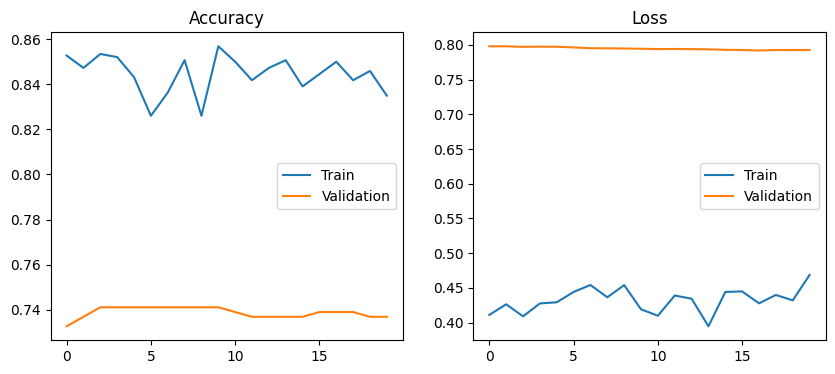

In [30]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss'); plt.legend()

plt.show()

In [31]:
from tensorflow.keras.preprocessing import image

img_path = "/kaggle/input/datasets/subhadeepppan/lungcancer/LungcancerDataSet/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000117 (4).png"

img = image.load_img(img_path, target_size=(128,128))
img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = img / 255.0

prediction = model.predict(img)
#confidence = np.max(prediction) * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [55]:
print(train_data.class_indices)

{'Bengin cases': 0, 'Malignant cases': 1, 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib': 2, 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa': 3, 'normal': 4, 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa': 5}


In [ ]:
'''# First print this once to confirm your class names
print(train_data.class_indices)

# Then use exact mapping
class_labels = {
    0: "Bengin cases",
    1: "Malignant cases", 
    2: "Normal (No Cancer)",
}

predicted_index = np.argmax(prediction)
result = class_labels[predicted_index]
confidence = np.max(prediction) * 100

img_rgb = image.load_img(img_path, target_size=(128, 128))
plt.imshow(img_rgb)
plt.axis("off")
print("Final Diagnosis:", result)
print(f"Confidence: {confidence:.2f}%")
plt.show()

Final Diagnosis: Squanous
Confidence: 96.90%


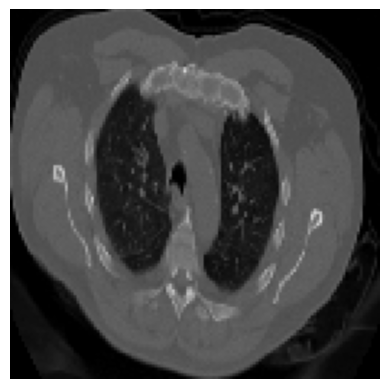

In [36]:
# First print this once to confirm your class names
#print(train_data.class_indices)

# Then use exact mapping
class_labels = {
    0: "Bengin cases",
    1: "Malignant cases", 
    2: "adenocarcinoma",
    3: "large cell",
    4: "Normal (No Cancer)",
    5: "Squanous",
}

predicted_index = np.argmax(prediction)
result = class_labels[predicted_index]
confidence = np.max(prediction) * 100

img_rgb = image.load_img(img_path, target_size=(128, 128))
plt.imshow(img_rgb)
plt.axis("off")
print("Final Diagnosis:", result)
print(f"Confidence: {confidence:.2f}%")
plt.show()

In [37]:
print(prediction)

[[5.7372825e-05 2.3024113e-05 3.0023200e-02 6.1107229e-04 2.6286350e-04
  9.6902239e-01]]


In [4]:
from tensorflow.keras.models import load_model

# Load directly from your uploaded Kaggle dataset
model = load_model("/kaggle/input/datasets/subhadeepppan/save-model/lung_multiclass_model (1).keras")
print("Model Loaded ✅")

I0000 00:00:1776574538.497040      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model Loaded ✅


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Final Diagnosis: Squamous
Confidence: 96.90%


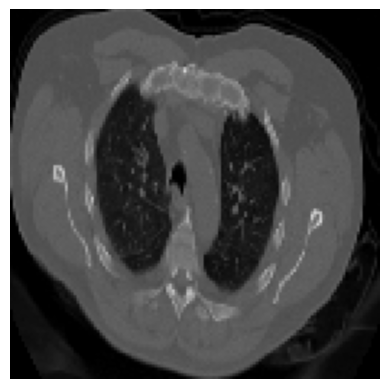

In [8]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/kaggle/input/datasets/subhadeepppan/lungcancer/LungcancerDataSet/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000117 (4).png"

img = image.load_img(img_path, target_size=(128,128))
img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = img / 255.0

prediction = model.predict(img)

class_labels = {
    0: "Benign cases",
    1: "Malignant cases",
    2: "Adenocarcinoma",
    3: "Large Cell",
    4: "Normal (No Cancer)",
    5: "Squamous",
}

predicted_index = np.argmax(prediction)
result = class_labels[predicted_index]
confidence = np.max(prediction) * 100

img_rgb = image.load_img(img_path, target_size=(128, 128))
plt.imshow(img_rgb)
plt.axis("off")
print("Final Diagnosis:", result)
print(f"Confidence: {confidence:.2f}%")
plt.show()